**Design and implement a Convolutional Neural Network (CNN) for image classification**

In [ ]:
import os
import zipfile
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [ ]:
ZIP_PATH = "archive.zip"
EXTRACT_DIR = "tomato_dataset"

if not os.path.exists(EXTRACT_DIR):
    with zipfile.ZipFile(ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

print("Dataset extracted successfully!")
print("Contents:")
print(os.listdir(EXTRACT_DIR))

Dataset extracted successfully!
Contents:
['class_distribution_train.png', 'tomato_data.ipynb', 'tomato_yolo_dataset', 'class_distribution_val.png']


In [ ]:
DATA_DIR = os.path.join(
    EXTRACT_DIR,
    "tomato_yolo_dataset"
)

print("Dataset path:", DATA_DIR)
print("\nContents:")

for item in os.listdir(DATA_DIR):
    print(item)

Dataset path: tomato_dataset/tomato_yolo_dataset

Contents:
images
labels


In [ ]:
IMAGES_DIR = os.path.join(
    DATA_DIR,
    "images"
)

LABELS_DIR = os.path.join(
    DATA_DIR,
    "labels"
)

print("Images directory:", IMAGES_DIR)
print("Labels directory:", LABELS_DIR)

print("\nImages folder contents:")
print(os.listdir(IMAGES_DIR)[:20])

print("\nLabels folder contents:")
print(os.listdir(LABELS_DIR)[:20])

Images directory: tomato_dataset/tomato_yolo_dataset/images
Labels directory: tomato_dataset/tomato_yolo_dataset/labels

Images folder contents:
['val', 'train']

Labels folder contents:
['val', 'train']


In [ ]:
TRAIN_IMAGES_DIR = os.path.join(
    IMAGES_DIR,
    "train"
)

VAL_IMAGES_DIR = os.path.join(
    IMAGES_DIR,
    "val"
)

TRAIN_LABELS_DIR = os.path.join(
    LABELS_DIR,
    "train"
)

VAL_LABELS_DIR = os.path.join(
    LABELS_DIR,
    "val"
)

print("Number of training images:",
      len(os.listdir(TRAIN_IMAGES_DIR)))

print("Number of validation images:",
      len(os.listdir(VAL_IMAGES_DIR)))

print("Number of training labels:",
      len(os.listdir(TRAIN_LABELS_DIR)))

print("Number of validation labels:",
      len(os.listdir(VAL_LABELS_DIR)))

print("\nSample training image files:")
print(os.listdir(TRAIN_IMAGES_DIR)[:10])

print("\nSample training label files:")
print(os.listdir(TRAIN_LABELS_DIR)[:10])

Number of training images: 14526
Number of validation images: 3632
Number of training labels: 14526
Number of validation labels: 3632

Sample training image files:
['TMBS_image (1674).jpg', 'TMEB_image (967).jpg', 'TMLB_image (979).jpg', 'TMYC_image (235).jpg', 'TMYC_image (5162).jpg', 'TMHE_image (272).jpg', 'TMEB_image (219).jpg', 'TMSM_image (982).jpg', 'TMHE_image (656).jpg', 'TMLB_image (440).jpg']

Sample training label files:
['TMEB_image (136).txt', 'TMYC_image (4334).txt', 'TMYC_image (3455).txt', 'TMSL_image (256).txt', 'TMSM_image (1113).txt', 'TMSL_image (1589).txt', 'TMSL_image (1581).txt', 'TMLB_image (543).txt', 'TMSM_image (743).txt', 'TMLM_image (587).txt']


In [ ]:
sample_label_file = os.path.join(
    TRAIN_LABELS_DIR,
    os.listdir(TRAIN_LABELS_DIR)[0]
)

print("Sample label file:")
print(sample_label_file)

print("\nLabel contents:")

with open(sample_label_file, "r") as file:
    print(file.read())

Sample label file:
tomato_dataset/tomato_yolo_dataset/labels/train/TMEB_image (136).txt

Label contents:
1 0.494141 0.501953 0.988281 0.996094


In [ ]:
class_ids = set()

for label_file in os.listdir(TRAIN_LABELS_DIR):

    if label_file.endswith(".txt"):

        label_path = os.path.join(
            TRAIN_LABELS_DIR,
            label_file
        )

        with open(label_path, "r") as file:

            for line in file:

                line = line.strip()

                if line:
                    class_id = int(
                        line.split()[0]
                    )

                    class_ids.add(class_id)


print("Class IDs found:")
print(sorted(class_ids))

print("Number of classes:",
      len(class_ids))

Class IDs found:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Number of classes: 10


In [ ]:
from collections import defaultdict, Counter

prefix_class_ids = defaultdict(Counter)

for label_file in os.listdir(TRAIN_LABELS_DIR):

    if not label_file.endswith(".txt"):
        continue

    # Get the corresponding image filename
    image_name = os.path.splitext(label_file)[0]

    # Filename prefix before "_image"
    prefix = image_name.split("_image")[0]

    label_path = os.path.join(
        TRAIN_LABELS_DIR,
        label_file
    )

    with open(label_path, "r") as file:

        for line in file:

            line = line.strip()

            if line:
                class_id = int(line.split()[0])
                prefix_class_ids[prefix][class_id] += 1

print("Filename Prefix → Class ID")

for prefix, counts in sorted(prefix_class_ids.items()):

    print(
        prefix,
        "->",
        counts
    )

Filename Prefix → Class ID
TMBS -> Counter({0: 1700})
TMEB -> Counter({1: 785})
TMHE -> Counter({9: 1286})
TMLB -> Counter({2: 1531})
TMLM -> Counter({3: 761})
TMMV -> Counter({8: 301})
TMSL -> Counter({4: 1431})
TMSM -> Counter({5: 1356})
TMTS -> Counter({6: 1113})
TMYC -> Counter({7: 4277})


In [ ]:
class_names = [
    "Bacterial Spot",
    "Early Blight",
    "Late Blight",
    "Leaf Mold",
    "Septoria Leaf Spot",
    "Spider Mites",
    "Target Spot",
    "Tomato Yellow Leaf Curl Virus",
    "Tomato Mosaic Virus",
    "Healthy"
]

NUM_CLASSES = len(class_names)

print("Number of Classes:", NUM_CLASSES)

print("\nClass Mapping:")

for class_id, class_name in enumerate(class_names):
    print(class_id, ":", class_name)

Number of Classes: 10

Class Mapping:
0 : Bacterial Spot
1 : Early Blight
2 : Late Blight
3 : Leaf Mold
4 : Septoria Leaf Spot
5 : Spider Mites
6 : Target Spot
7 : Tomato Yellow Leaf Curl Virus
8 : Tomato Mosaic Virus
9 : Healthy


In [ ]:
train_image_paths = []
train_labels = []

for image_file in os.listdir(TRAIN_IMAGES_DIR):

    if image_file.lower().endswith(
        (".jpg", ".jpeg", ".png")
    ):

        image_path = os.path.join(
            TRAIN_IMAGES_DIR,
            image_file
        )

        # Corresponding YOLO label file
        label_file = os.path.splitext(
            image_file
        )[0] + ".txt"

        label_path = os.path.join(
            TRAIN_LABELS_DIR,
            label_file
        )

        # Make sure label exists
        if os.path.exists(label_path):

            with open(
                label_path,
                "r"
            ) as file:

                lines = [
                    line.strip()
                    for line in file
                    if line.strip()
                ]

            if len(lines) > 0:

                # First value = class ID
                class_id = int(
                    lines[0].split()[0]
                )

                train_image_paths.append(
                    image_path
                )

                train_labels.append(
                    class_id
                )


train_image_paths = np.array(
    train_image_paths
)

train_labels = np.array(
    train_labels
)


print("Training Images:",
      len(train_image_paths))

print("Training Labels:",
      len(train_labels))

Training Images: 14526
Training Labels: 14526


In [ ]:
val_image_paths = []
val_labels = []

for image_file in os.listdir(VAL_IMAGES_DIR):

    if image_file.lower().endswith(
        (".jpg", ".jpeg", ".png")
    ):

        image_path = os.path.join(
            VAL_IMAGES_DIR,
            image_file
        )

        # Corresponding YOLO label file
        label_file = os.path.splitext(
            image_file
        )[0] + ".txt"

        label_path = os.path.join(
            VAL_LABELS_DIR,
            label_file
        )

        # Make sure label exists
        if os.path.exists(label_path):

            with open(
                label_path,
                "r"
            ) as file:

                lines = [
                    line.strip()
                    for line in file
                    if line.strip()
                ]

            if len(lines) > 0:

                # First value = class ID
                class_id = int(
                    lines[0].split()[0]
                )

                val_image_paths.append(
                    image_path
                )

                val_labels.append(
                    class_id
                )


val_image_paths = np.array(
    val_image_paths
)

val_labels = np.array(
    val_labels
)


print("Validation Images:",
      len(val_image_paths))

print("Validation Labels:",
      len(val_labels))

Validation Images: 3632
Validation Labels: 3632


In [ ]:
train_class_counts = np.bincount(
    train_labels,
    minlength=NUM_CLASSES
)

val_class_counts = np.bincount(
    val_labels,
    minlength=NUM_CLASSES
)


distribution_df = pd.DataFrame({
    "Class ID": range(NUM_CLASSES),
    "Disease Class": class_names,
    "Training Images": train_class_counts,
    "Validation Images": val_class_counts
})


display(distribution_df)

,Class ID,Disease Class,Training Images,Validation Images
0,0,Bacterial Spot,1700,427
1,1,Early Blight,782,218
2,2,Late Blight,1528,379
3,3,Leaf Mold,761,191
4,4,Septoria Leaf Spot,1426,345
5,5,Spider Mites,1356,320
6,6,Target Spot,1112,292
7,7,Tomato Yellow Leaf Curl Virus,4274,1083
8,8,Tomato Mosaic Virus,301,72
9,9,Healthy,1286,305


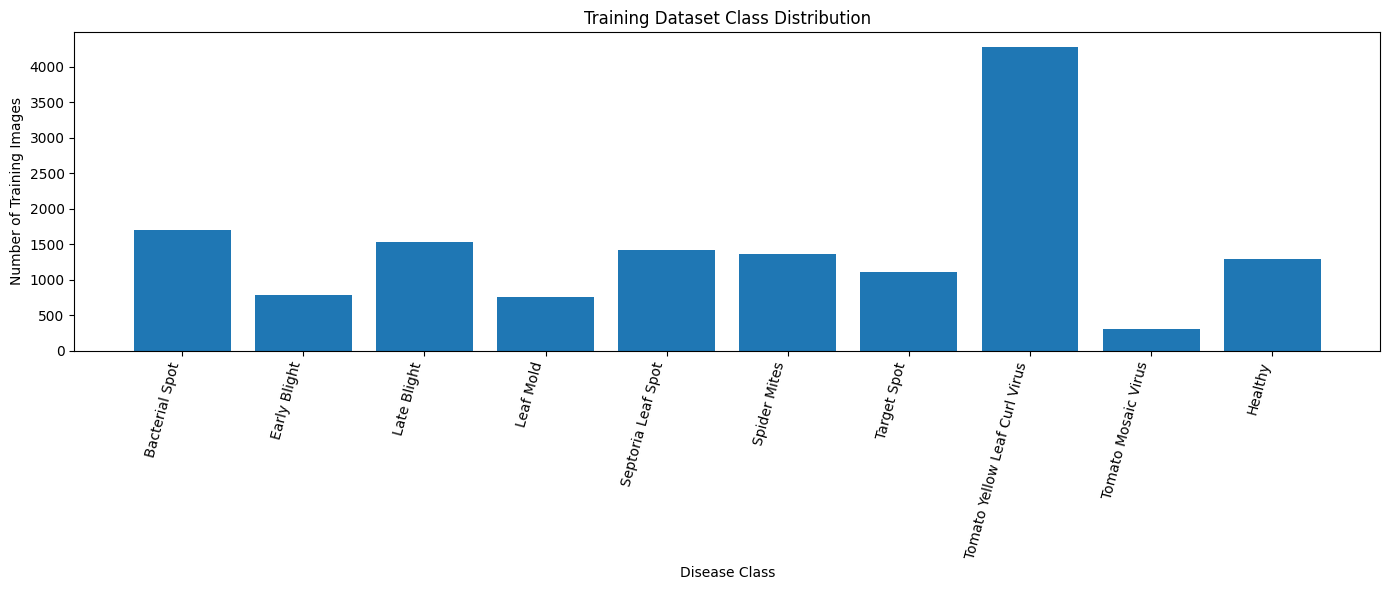

In [ ]:
plt.figure(figsize=(14, 6))

plt.bar(
    range(NUM_CLASSES),
    train_class_counts
)

plt.xticks(
    range(NUM_CLASSES),
    class_names,
    rotation=75,
    ha="right"
)

plt.xlabel("Disease Class")
plt.ylabel("Number of Training Images")
plt.title("Training Dataset Class Distribution")

plt.tight_layout()
plt.show()

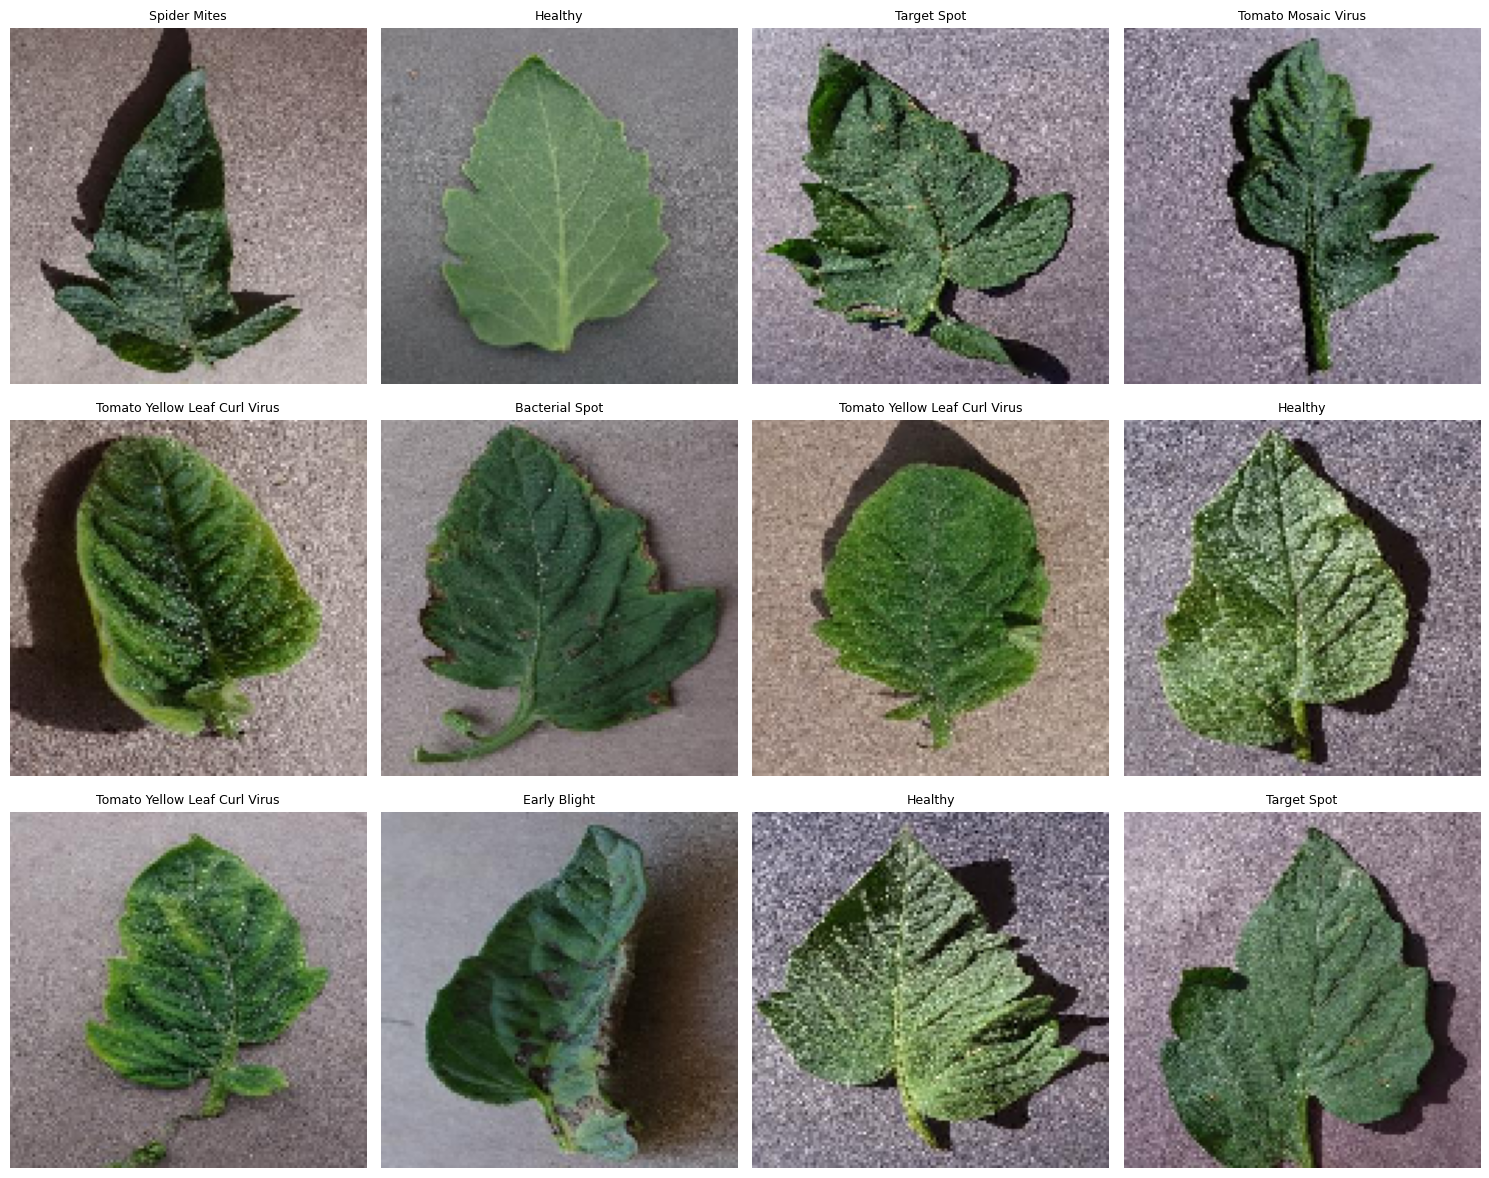

In [ ]:
id="cell14"
plt.figure(figsize=(15, 12))

sample_indices = np.random.choice(
    len(train_image_paths),
    12,
    replace=False
)

for i, idx in enumerate(sample_indices):

    image_path = train_image_paths[idx]
    label = train_labels[idx]

    image = tf.keras.utils.load_img(
        image_path,
        target_size=(128, 128)
    )

    plt.subplot(3, 4, i + 1)

    plt.imshow(image)

    plt.title(
        class_names[label],
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE


def load_and_preprocess_image(path, label):

    # Read image
    image = tf.io.read_file(path)

    # Decode JPEG image
    image = tf.image.decode_jpeg(
        image,
        channels=3
    )

    # Resize image
    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    # Normalize pixel values from 0-255 to 0-1
    image = tf.cast(
        image,
        tf.float32
    ) / 255.0

    return image, label


def create_dataset(
    paths,
    labels,
    shuffle=False
):

    dataset = tf.data.Dataset.from_tensor_slices(
        (paths, labels)
    )

    if shuffle:
        dataset = dataset.shuffle(
            buffer_size=len(paths),
            seed=42
        )

    dataset = dataset.map(
        load_and_preprocess_image,
        num_parallel_calls=AUTOTUNE
    )

    dataset = dataset.batch(
        BATCH_SIZE
    )

    dataset = dataset.prefetch(
        AUTOTUNE
    )

    return dataset


train_ds = create_dataset(
    train_image_paths,
    train_labels,
    shuffle=True
)

val_ds = create_dataset(
    val_image_paths,
    val_labels
)

print("Training and validation datasets created successfully!")

Training and validation datasets created successfully!


In [ ]:
for images, labels_batch in train_ds.take(1):

    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels_batch.shape)

Image batch shape: (32, 128, 128, 3)
Label batch shape: (32,)


In [ ]:
data_augmentation = tf.keras.Sequential([

    tf.keras.layers.RandomFlip(
        "horizontal"
    ),

    tf.keras.layers.RandomRotation(
        0.10
    ),

    tf.keras.layers.RandomZoom(
        0.10
    ),

    tf.keras.layers.RandomContrast(
        0.10
    )

])

print("Data augmentation created successfully!")

Data augmentation created successfully!


In [ ]:
model = tf.keras.Sequential([

    # Input Layer
    tf.keras.layers.Input(
        shape=(128, 128, 3)
    ),

    # Data Augmentation
    data_augmentation,

    # Convolution Block 1
    tf.keras.layers.Conv2D(
        32,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Convolution Block 2
    tf.keras.layers.Conv2D(
        64,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Convolution Block 3
    tf.keras.layers.Conv2D(
        128,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Convolution Block 4
    tf.keras.layers.Conv2D(
        256,
        (3, 3),
        activation="relu",
        padding="same"
    ),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),

    # Flatten
    tf.keras.layers.Flatten(),

    # Fully Connected Layer
    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    # Dropout
    tf.keras.layers.Dropout(
        0.5
    ),

    # Output Layer
    tf.keras.layers.Dense(
        NUM_CLASSES,
        activation="softmax"
    )
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,488,906 (9.49 MB)

 Trainable params: 2,487,946 (9.49 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [ ]:
callbacks = [

    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )

]

print("Callbacks created successfully!")

Callbacks created successfully!


In [ ]:
EPOCHS = 20

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)

Epoch 1/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 36s 57ms/step - accuracy: 0.4409 - loss: 1.7658 - val_accuracy: 0.4130 - val_loss: 1.8332 - learning_rate: 0.0010
Epoch 2/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 25s 55ms/step - accuracy: 0.5344 - loss: 1.3776 - val_accuracy: 0.4725 - val_loss: 1.6635 - learning_rate: 0.0010
Epoch 3/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.5888 - loss: 1.2203 - val_accuracy: 0.3855 - val_loss: 1.7499 - learning_rate: 0.0010
Epoch 4/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 26s 57ms/step - accuracy: 0.6286 - loss: 1.0942 - val_accuracy: 0.4683 - val_loss: 5.3119 - learning_rate: 0.0010
Epoch 5/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 25s 55ms/step - accuracy: 0.6812 - loss: 0.9201 - val_accuracy: 0.6407 - val_loss: 1.0183 - learning_rate: 5.0000e-04
Epoch 6/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 41s 55ms/step - accuracy: 0.7064 - loss: 0.8282 - val_accuracy: 0.7979 - val_loss: 0.5942 - learning_rate: 5.0000e-04
Epoch 7/20
454/454 ━━━━━━━━━━━━━━━━━━━━ 25s 56ms/step - accuracy: 0.

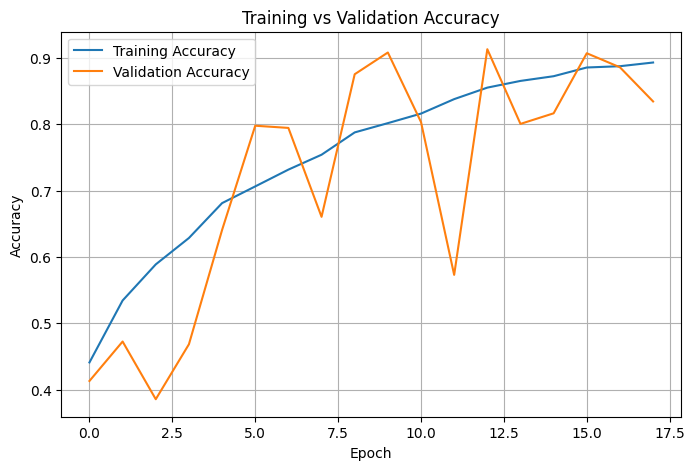

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title(
    "Training vs Validation Accuracy"
)

plt.legend()

plt.grid(True)

plt.show()

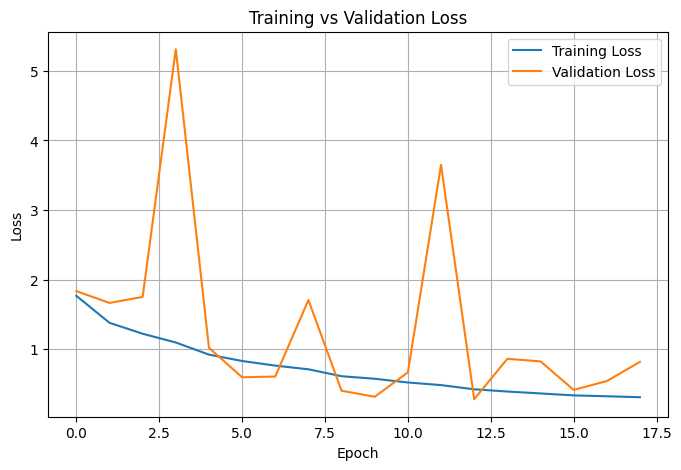

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Training vs Validation Loss"
)

plt.legend()

plt.grid(True)

plt.show()

In [ ]:
val_loss, val_accuracy = model.evaluate(
    val_ds,
    verbose=1
)

print("\nFinal Validation Loss:",
      val_loss)

print(
    "Final Validation Accuracy:",
    val_accuracy
)

114/114 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9133 - loss: 0.2785

Final Validation Loss: 0.2785232365131378
Final Validation Accuracy: 0.9132709503173828


In [ ]:
y_true = []
y_pred = []

for images, labels_batch in val_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(
        labels_batch.numpy()
    )

    y_pred.extend(
        predicted_classes
    )


y_true = np.array(y_true)
y_pred = np.array(y_pred)


print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

                               precision    recall  f1-score   support

               Bacterial Spot     0.9419    0.9485    0.9452       427
                 Early Blight     0.8768    0.8165    0.8456       218
                  Late Blight     0.9295    0.9393    0.9344       379
                    Leaf Mold     0.9419    0.7644    0.8439       191
           Septoria Leaf Spot     0.8783    0.9623    0.9184       345
                 Spider Mites     0.8153    0.8000    0.8076       320
                  Target Spot     0.7322    0.9178    0.8146       292
Tomato Yellow Leaf Curl Virus     0.9971    0.9464    0.9711      1083
          Tomato Mosaic Virus     0.9583    0.6389    0.7667        72
                      Healthy     0.9327    1.0000    0.9652       305

                     accuracy                         0.9133      3632
                    macro avg     0.9004    0.8734    0.8813      3632
                 weighted avg     0.9187    0.9133    0.9135      3632



<Figure size 1000x800 with 0 Axes>

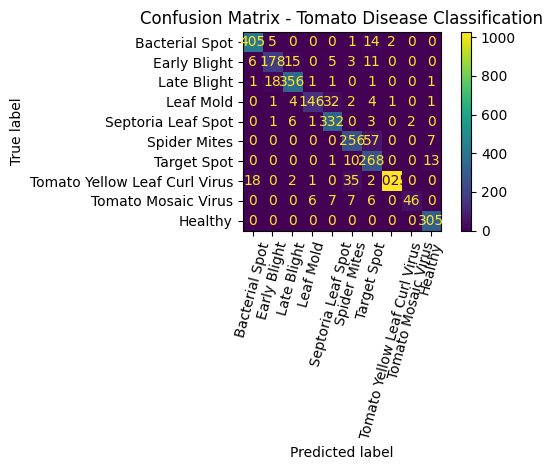

In [ ]:
cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(10, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    xticks_rotation=75,
    values_format="d"
)

plt.title(
    "Confusion Matrix - Tomato Disease Classification"
)

plt.tight_layout()
plt.show()

In [ ]:
MODEL_PATH = "tomato_disease_cnn.keras"

model.save(MODEL_PATH)

print("Model saved successfully!")
print("Saved model:", MODEL_PATH)

Model saved successfully!
Saved model: tomato_disease_cnn.keras


In [ ]:
import json

CLASS_NAMES_PATH = "tomato_class_names.json"

with open(CLASS_NAMES_PATH, "w") as file:
    json.dump(
        class_names,
        file,
        indent=4
    )

print("Class names saved successfully!")
print("Saved file:", CLASS_NAMES_PATH)

Class names saved successfully!
Saved file: tomato_class_names.json


In [ ]:
sample_index = random.randint(
    0,
    len(val_image_paths) - 1
)

sample_image_path = val_image_paths[
    sample_index
]

actual_label = val_labels[
    sample_index
]

image = tf.keras.utils.load_img(
    sample_image_path,
    target_size=IMG_SIZE
)

image_array = tf.keras.utils.img_to_array(
    image
)

image_array = image_array / 255.0

image_batch = np.expand_dims(
    image_array,
    axis=0
)

prediction = model.predict(
    image_batch,
    verbose=0
)

predicted_label = np.argmax(
    prediction[0]
)

confidence = np.max(
    prediction[0]
) * 100

print("Image:", os.path.basename(sample_image_path))
print("Actual Class:", class_names[actual_label])
print("Predicted Class:", class_names[predicted_label])
print("Confidence: {:.2f}%".format(confidence))

Image: TMYC_image (3747).jpg
Actual Class: Tomato Yellow Leaf Curl Virus
Predicted Class: Tomato Yellow Leaf Curl Virus
Confidence: 100.00%


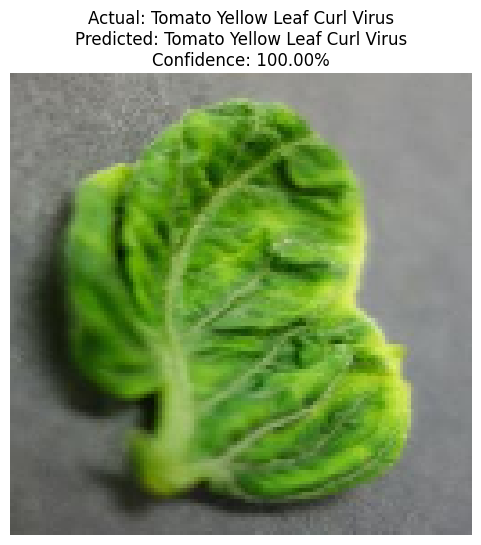

In [ ]:
plt.figure(figsize=(6, 6))

plt.imshow(image)

plt.title(
    f"Actual: {class_names[actual_label]}\n"
    f"Predicted: {class_names[predicted_label]}\n"
    f"Confidence: {confidence:.2f}%"
)

plt.axis("off")

plt.show()

In [ ]:
print(
    "Model exists:",
    os.path.exists(MODEL_PATH)
)

if os.path.exists(MODEL_PATH):

    model_size_mb = (
        os.path.getsize(MODEL_PATH)
        / (1024 ** 2)
    )

    print(
        "Model size: {:.2f} MB".format(
            model_size_mb
        )
    )

Model exists: True
Model size: 28.56 MB


In [ ]:
print("=" * 60)
print("FINAL CNN MODEL SUMMARY")
print("=" * 60)

print("Dataset:")
print("  Training Images   :", len(train_image_paths))
print("  Validation Images :", len(val_image_paths))
print("  Number of Classes :", NUM_CLASSES)

print("\nModel:")
print("  Input Size        : 128 x 128 x 3")
print("  Architecture      : 4 Conv Blocks")
print("  Filters           : 32 -> 64 -> 128 -> 256")
print("  Dense Layer       : 128 neurons")
print("  Dropout           : 0.5")

print("\nPerformance:")
print(
    "  Validation Accuracy : {:.2f}%".format(
        val_accuracy * 100
    )
)

print(
    "  Validation Loss     : {:.4f}".format(
        val_loss
    )
)

print("\nSaved Files:")
print("  Model       :", MODEL_PATH)
print("  Class Names :", CLASS_NAMES_PATH)

print("=" * 60)

FINAL CNN MODEL SUMMARY
Dataset:
  Training Images   : 14526
  Validation Images : 3632
  Number of Classes : 10

Model:
  Input Size        : 128 x 128 x 3
  Architecture      : 4 Conv Blocks
  Filters           : 32 -> 64 -> 128 -> 256
  Dense Layer       : 128 neurons
  Dropout           : 0.5

Performance:
  Validation Accuracy : 91.33%
  Validation Loss     : 0.2785

Saved Files:
  Model       : tomato_disease_cnn.keras
  Class Names : tomato_class_names.json
